Build VAE

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np


inputs = Input(shape=(784,))
h = Dense(128, activation='relu')(inputs)
latent = Dense(2)(h)


decoder_h = Dense(128, activation='relu')
decoder_out = Dense(784, activation='sigmoid')

h_decoded = decoder_h(latent)
outputs = decoder_out(h_decoded)


vae = Model(inputs, outputs)


vae.compile(optimizer='adam', loss='binary_crossentropy')

print(vae.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,258 (790.07 KB)

 Trainable params: 202,258 (790.07 KB)

 Non-trainable params: 0 (0.00 B)

None


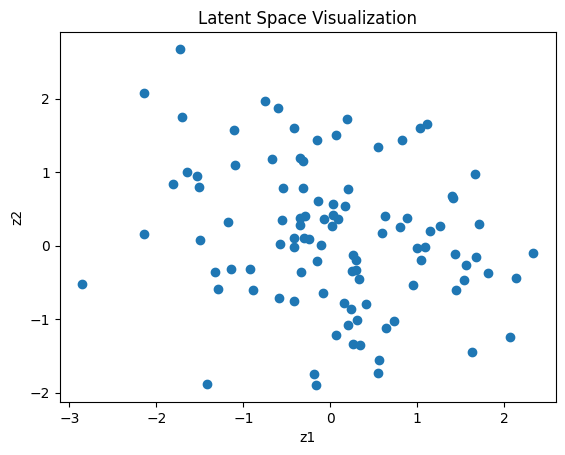

In [2]:

z = np.random.randn(100, 2)

plt.scatter(z[:,0], z[:,1])
plt.title("Latent Space Visualization")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Train GAN

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


generator = Sequential([
    Dense(128, activation='relu', input_dim=100),
    Dense(784, activation='sigmoid')
])


discriminator = Sequential([
    Dense(128, activation='relu', input_dim=784),
    Dense(1, activation='sigmoid')
])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("GAN Components Created Successfully")

GAN Components Created Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


GCN

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GCNLayer(nn.Module):

    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()

        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)


x = torch.rand((5, 10))

gcn = GCNLayer(10, 2)

output = gcn(x)

print(output)

tensor([[ 0.3694, -0.7309],
        [ 0.0270, -0.4221],
        [ 0.0603, -0.9044],
        [ 0.2124, -0.7191],
        [ 0.0807, -0.7785]], grad_fn=<AddmmBackward0>)
